# RSNN on PTB-XL ECG Dataset

**Goal**: Validate that the RSNN architecture from SHD generalises to continuous-valued time series classification. This bridges event-based audio (SHD) to continuous financial data.

**SHD Results (carried forward)**:
| Architecture | SHD Test Acc |
|---|---|
| 2L Feed-Forward | 49.7% |
| RSNN 128 + dropout | 58.2% |
| RSNN 256 + dropout | 62.3% |
| Best Effort RSNN | 78.7% |

**PTB-XL Dataset**:
- 21,799 clinical 12-lead ECG recordings, 10 seconds each
- 5 diagnostic superclasses: NORM, MI, STTC, CD, HYP
- Multi-label → we use single-label (highest likelihood) for direct comparison
- Published baselines: LSTM ~85-88%, CNN ~83-86%

**Key experiment**: Compare 4 spike encoding methods for continuous data:
1. Direct input (no encoding) — baseline
2. Rate coding
3. Temporal contrast (derivative-based)
4. Delta modulation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import ast
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


In [2]:
import subprocess
subprocess.check_call(['pip', 'install', 'wfdb', '--break-system-packages', '-q'])
import wfdb
print(f"wfdb version: {wfdb.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.4 MB/s eta 0:00:00
wfdb version: 4.3.1


## 1. Load PTB-XL Dataset

Add the PTB-XL dataset to your Kaggle notebook:
- Go to **Add Data** → Search **"ptb-xl-dataset"** by khyeh0719 → Add
- The data will be at `/kaggle/input/ptb-xl-dataset/`

In [3]:
import glob

# Auto-detect the PTB-XL data directory
DATA_DIR = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "ptbxl_database.csv" in files:
        DATA_DIR = root
        break

if DATA_DIR is None:
    # Fallback: search for any csv with 'ptbxl' in name
    matches = glob.glob("/kaggle/input/**/ptbxl_database.csv", recursive=True)
    if matches:
        DATA_DIR = os.path.dirname(matches[0])

if DATA_DIR is None:
    # Last resort: just list what's actually there
    print("Could not find ptbxl_database.csv. Here's what exists:")
    for root, dirs, files in os.walk("/kaggle/input"):
        level = root.replace("/kaggle/input", "").count(os.sep)
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 3:
            for f in files[:5]:
                print(f"{indent}  {f}")
    raise FileNotFoundError("PTB-XL dataset not found. Check the dataset name in Add Data.")

print(f"Data directory: {DATA_DIR}")
print("Contents:")
for f in sorted(os.listdir(DATA_DIR))[:15]:
    path = os.path.join(DATA_DIR, f)
    if os.path.isdir(path):
        print(f"  [DIR] {f}/")
    else:
        size = os.path.getsize(path)
        print(f"  {f} ({size/1e6:.1f} MB)")

Data directory: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
Contents:
  LICENSE.txt (0.0 MB)
  RECORDS (1.1 MB)
  SHA256SUMS.txt (8.3 MB)
  example_physionet.py (0.0 MB)
  ptbxl_database.csv (6.6 MB)
  [DIR] records100/
  [DIR] records500/
  scp_statements.csv (0.0 MB)


## 2. Parse Metadata & Extract Superclass Labels

In [4]:
# Load metadata
csv_path = os.path.join(DATA_DIR, "ptbxl_database.csv")
df = pd.read_csv(csv_path, index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSample scp_codes: {df.scp_codes.iloc[0]}")

# Load SCP statement descriptions
scp_path = os.path.join(DATA_DIR, "scp_statements.csv")
scp_df = pd.read_csv(scp_path, index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1]  # Keep only diagnostic statements
print(f"\nDiagnostic SCP statements: {len(scp_df)}")
print(f"Superclasses: {sorted(scp_df.diagnostic_class.unique())}")

Total records: 21837
Columns: ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

Sample scp_codes: {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}

Diagnostic SCP statements: 44
Superclasses: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


In [5]:
# Map each record to its diagnostic superclass
# For multi-label records, take the class with highest likelihood
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
class_to_idx = {c: i for i, c in enumerate(SUPERCLASSES)}

def get_superclass(scp_dict):
    """Get single superclass label (highest likelihood diagnostic)."""
    best_class = None
    best_likelihood = 0
    for key, likelihood in scp_dict.items():
        if key in scp_df.index:
            superclass = scp_df.loc[key].diagnostic_class
            if superclass in SUPERCLASSES and likelihood > best_likelihood:
                best_likelihood = likelihood
                best_class = superclass
    return best_class

df['superclass'] = df.scp_codes.apply(get_superclass)
df = df.dropna(subset=['superclass'])
df['label'] = df.superclass.map(class_to_idx)

print(f"Records with valid superclass: {len(df)}")
print(f"\nClass distribution:")
for cls in SUPERCLASSES:
    n = (df.superclass == cls).sum()
    print(f"  {cls}: {n} ({n/len(df)*100:.1f}%)")

# Use the official recommended splits (strat_fold column)
# Folds 1-8: train, Fold 9: val, Fold 10: test
df_train = df[df.strat_fold <= 8]
df_val = df[df.strat_fold == 9]
df_test = df[df.strat_fold == 10]
print(f"\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Records with valid superclass: 21417

Class distribution:
  NORM: 9260 (43.2%)
  MI: 4199 (19.6%)
  STTC: 3342 (15.6%)
  CD: 3325 (15.5%)
  HYP: 1291 (6.0%)

Train: 17100 | Val: 2155 | Test: 2162


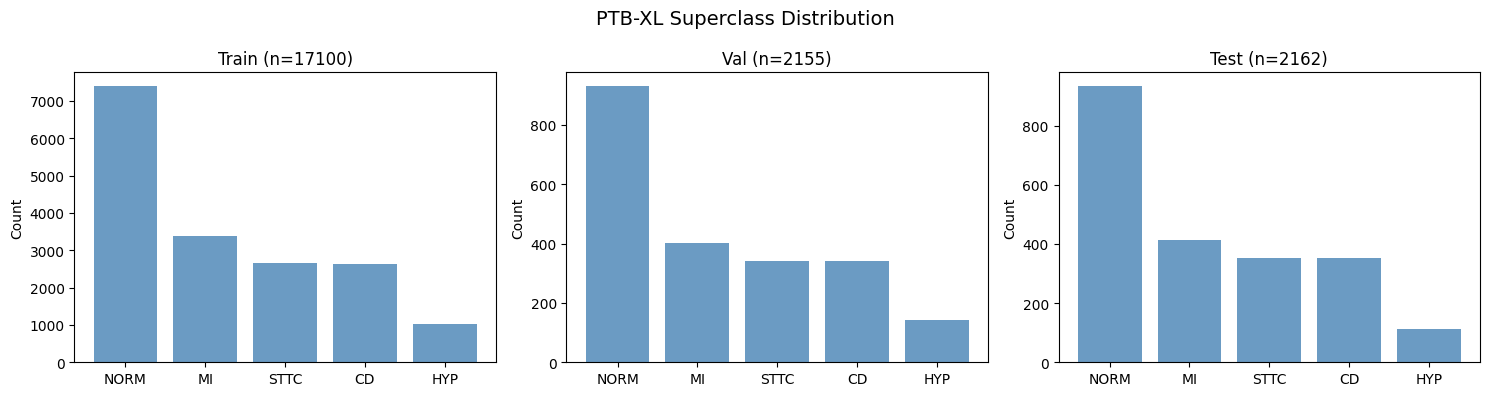

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, subset) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = subset.superclass.value_counts().reindex(SUPERCLASSES)
    ax.bar(SUPERCLASSES, counts.values, color='steelblue', alpha=0.8)
    ax.set_title(f"{name} (n={len(subset)})")
    ax.set_ylabel("Count")
plt.suptitle("PTB-XL Superclass Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Load ECG Waveforms

Uses the 100Hz downsampled version (1000 timesteps per 10-second recording) for efficiency. Each record has 12 leads

In [7]:
def load_ecg_data(df_subset, data_dir, sampling_rate=100):
    """Load ECG waveforms for a dataframe subset."""
    # Use records100 for 100Hz data
    if sampling_rate == 100:
        path_col = 'filename_lr'
    else:
        path_col = 'filename_hr'
    
    signals = []
    labels = []
    skipped = 0
    
    for idx, row in df_subset.iterrows():
        try:
            record_path = os.path.join(data_dir, row[path_col])
            # Remove .hea extension if present
            if record_path.endswith('.hea'):
                record_path = record_path[:-4]
            record = wfdb.rdrecord(record_path)
            sig = record.p_signal  # shape: (1000, 12) for 100Hz
            
            if sig is not None and sig.shape[0] > 0:
                signals.append(sig.astype(np.float32))
                labels.append(row['label'])
        except Exception as e:
            skipped += 1
            if skipped <= 3:
                print(f"  Skipped {row[path_col]}: {e}")
    
    if skipped > 0:
        print(f"  Total skipped: {skipped}")
    
    return np.array(signals), np.array(labels, dtype=np.int64)

print("Loading training data...")
X_train, y_train = load_ecg_data(df_train, DATA_DIR, sampling_rate=100)
print(f"  Shape: {X_train.shape}, Labels: {y_train.shape}")

print("Loading validation data...")
X_val, y_val = load_ecg_data(df_val, DATA_DIR, sampling_rate=100)
print(f"  Shape: {X_val.shape}, Labels: {y_val.shape}")

print("Loading test data...")
X_test, y_test = load_ecg_data(df_test, DATA_DIR, sampling_rate=100)
print(f"  Shape: {X_test.shape}, Labels: {y_test.shape}")

print(f"\nECG shape per record: {X_train[0].shape}  (timesteps x leads)")
print(f"Duration: {X_train[0].shape[0]/100:.1f}s at 100Hz")

Loading training data...
  Shape: (17100, 1000, 12), Labels: (17100,)
Loading validation data...
  Shape: (2155, 1000, 12), Labels: (2155,)
Loading test data...
  Shape: (2162, 1000, 12), Labels: (2162,)

ECG shape per record: (1000, 12)  (timesteps x leads)
Duration: 10.0s at 100Hz


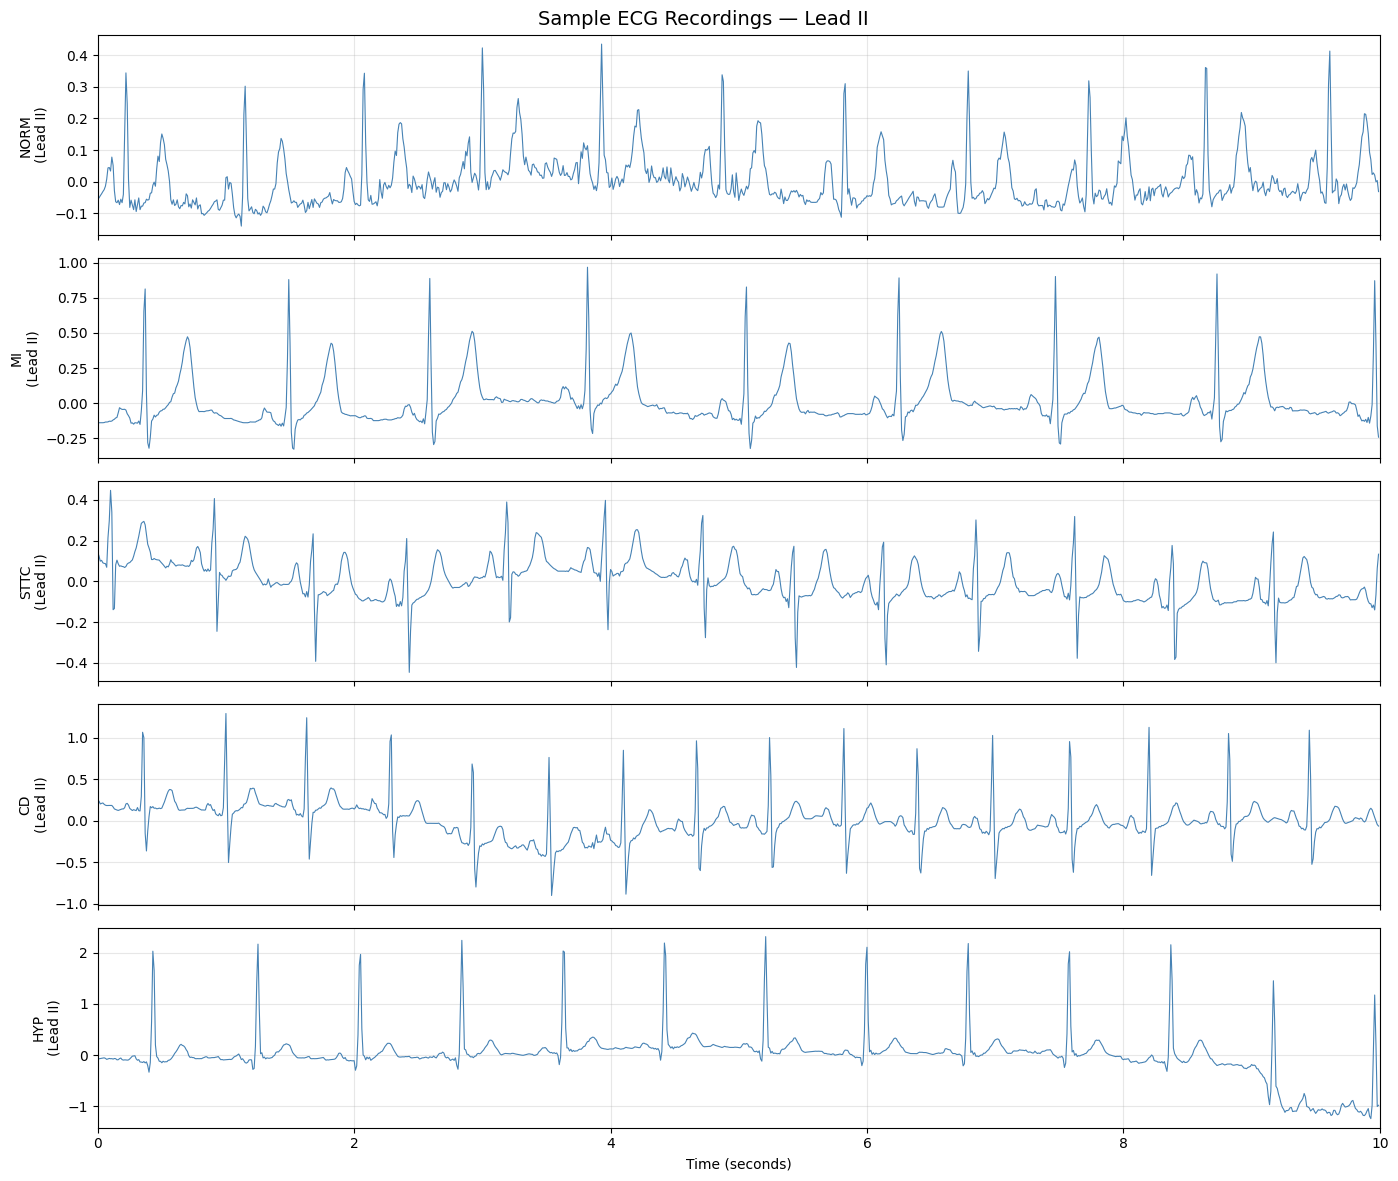

In [8]:
# Show sample ECGs from each class
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for cls_idx, cls_name in enumerate(SUPERCLASSES):
    ax = axes[cls_idx]
    idx = np.where(y_train == cls_idx)[0][0]
    ecg = X_train[idx]
    t = np.arange(ecg.shape[0]) / 100  # seconds
    
    # Plot lead II (most diagnostic)
    ax.plot(t, ecg[:, 1], color='steelblue', linewidth=0.8)
    ax.set_ylabel(f"{cls_name}\n(Lead II)")
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("Sample ECG Recordings — Lead II", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Preprocessing & Spike Encoding

Normalize ECG signals, then apply 4 different encoding strategies

In [9]:
# Z-score normalization per channel (computed on training set only)
train_mean = X_train.mean(axis=(0, 1), keepdims=True)  # shape (1, 1, 12)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print(f"Normalized range — train: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")
print(f"Mean: {X_train_norm.mean():.4f}, Std: {X_train_norm.std():.4f}")

Normalized range — train: [-77.45, 64.69]
Mean: 0.0000, Std: 1.0215


In [10]:
class SpikeEncoder:
    """
    Spike encoding methods for continuous time series.
    Each method converts [T, C] continuous signals to SNN-compatible inputs.
    """
    
    @staticmethod
    def direct(signal):
        """No encoding — feed continuous values directly into LIF layer."""
        return signal  # [T, C]
    
    @staticmethod
    def rate_coding(signal, n_repeat=1):
        """Rate coding: normalize to [0,1] and use as firing probabilities."""
        # Clip to [0, 1] range
        sig_min = signal.min(axis=0, keepdims=True)
        sig_max = signal.max(axis=0, keepdims=True)
        normalized = (signal - sig_min) / (sig_max - sig_min + 1e-8)
        # Generate spikes with probability = normalized value
        spikes = (np.random.rand(*normalized.shape) < normalized).astype(np.float32)
        return spikes  # [T, C]
    
    @staticmethod
    def temporal_contrast(signal, threshold=0.5):
        """Temporal contrast: spike when derivative exceeds threshold.
        Produces ON spikes (+1) and OFF spikes (-1) or separate channels."""
        T, C = signal.shape
        diff = np.diff(signal, axis=0, prepend=signal[:1])
        
        # ON spikes: positive change > threshold
        on_spikes = (diff > threshold).astype(np.float32)
        # OFF spikes: negative change < -threshold
        off_spikes = (diff < -threshold).astype(np.float32)
        
        # Concatenate ON and OFF channels → [T, 2*C]
        encoded = np.concatenate([on_spikes, off_spikes], axis=1)
        return encoded  # [T, 2*C]
    
    @staticmethod
    def delta_modulation(signal, threshold=0.3):
        """Delta modulation: spike when signal deviates from reference by threshold."""
        T, C = signal.shape
        spikes = np.zeros_like(signal)
        reference = signal[0].copy()
        
        for t in range(1, T):
            diff = signal[t] - reference
            up = diff > threshold
            down = diff < -threshold
            spikes[t, up] = 1.0
            spikes[t, down] = -1.0  # Or could use separate channels
            reference[up] = signal[t, up]
            reference[down] = signal[t, down]
        
        return spikes  # [T, C]

# Test encoding on one sample
sample = X_train_norm[0]
print("Encoding outputs for sample ECG:")
for name, fn, kwargs in [
    ("Direct", SpikeEncoder.direct, {}),
    ("Rate coding", SpikeEncoder.rate_coding, {}),
    ("Temporal contrast (th=0.5)", SpikeEncoder.temporal_contrast, {"threshold": 0.5}),
    ("Delta modulation (th=0.3)", SpikeEncoder.delta_modulation, {"threshold": 0.3}),
]:
    enc = fn(sample, **kwargs)
    print(f"  {name}: shape={enc.shape}, mean={enc.mean():.4f}, sparsity={1 - (enc != 0).mean():.2%}")

Encoding outputs for sample ECG:
  Direct: shape=(1000, 12), mean=0.0039, sparsity=0.00%
  Rate coding: shape=(1000, 12), mean=0.4538, sparsity=54.62%
  Temporal contrast (th=0.5): shape=(1000, 24), mean=0.0233, sparsity=97.67%
  Delta modulation (th=0.3): shape=(1000, 12), mean=0.0059, sparsity=86.42%


## 5. Dataset & DataLoaders

In [11]:
class ECGDataset(Dataset):
    def __init__(self, X, y, encoding='direct', n_time_bins=250, **enc_kwargs):
        self.X = X  # [N, T, C] normalized
        self.y = torch.tensor(y, dtype=torch.long)
        self.encoding = encoding
        self.n_time_bins = n_time_bins
        self.enc_kwargs = enc_kwargs
        self.n_samples = len(X)
        
        # Determine input size based on encoding
        sample_enc = self._encode(X[0])
        self.input_size = sample_enc.shape[1]
        self.n_classes = len(np.unique(y))
    
    def _encode(self, signal):
        # Temporal downsampling: 1000 -> n_time_bins
        T_orig = signal.shape[0]
        if T_orig != self.n_time_bins:
            indices = np.linspace(0, T_orig - 1, self.n_time_bins).astype(int)
            signal = signal[indices]
        
        if self.encoding == 'direct':
            return SpikeEncoder.direct(signal)
        elif self.encoding == 'rate':
            return SpikeEncoder.rate_coding(signal, **self.enc_kwargs)
        elif self.encoding == 'temporal_contrast':
            return SpikeEncoder.temporal_contrast(signal, **self.enc_kwargs)
        elif self.encoding == 'delta':
            return SpikeEncoder.delta_modulation(signal, **self.enc_kwargs)
        else:
            raise ValueError(f"Unknown encoding: {self.encoding}")
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        encoded = self._encode(self.X[idx])
        return torch.tensor(encoded, dtype=torch.float32), self.y[idx]

def create_ecg_loaders(X_train, y_train, X_val, y_val, X_test, y_test,
                       encoding='direct', n_time_bins=250, batch_size=128, **enc_kwargs):
    train_ds = ECGDataset(X_train, y_train, encoding, n_time_bins, **enc_kwargs)
    val_ds = ECGDataset(X_val, y_val, encoding, n_time_bins, **enc_kwargs)
    test_ds = ECGDataset(X_test, y_test, encoding, n_time_bins, **enc_kwargs)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, 
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)
    
    print(f"Encoding: {encoding} | Input: [{n_time_bins}, {train_ds.input_size}] | Classes: {train_ds.n_classes}")
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader, train_ds.input_size, train_ds.n_classes

# Create default loaders (direct input)
train_loader, val_loader, test_loader, input_size, n_classes = create_ecg_loaders(
    X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test,
    encoding='direct', n_time_bins=250, batch_size=128
)
x_sample, y_sample = next(iter(train_loader))
print(f"Batch: {x_sample.shape}, Labels: {y_sample.shape}")

Encoding: direct | Input: [250, 12] | Classes: 5
Train: 17100 | Val: 2155 | Test: 2162
Batch: torch.Size([128, 250, 12]), Labels: torch.Size([128])


## 6. SNN Architecture (Transferred from SHD)

**Identical** components to SHD notebook: SurrogateSpike, LIFLayer (with dropout), ReadoutLayer, SNN class. The only change is `input_size` (12 ECG leads instead of 700 cochlear channels).

In [12]:
class SurrogateSpike(torch.autograd.Function):
    beta = 40.0
    @staticmethod
    def forward(ctx, membrane_potential, threshold=1.0):
        ctx.save_for_backward(membrane_potential)
        ctx.threshold = threshold
        return (membrane_potential >= threshold).float()
    @staticmethod
    def backward(ctx, grad_output):
        membrane_potential, = ctx.saved_tensors
        v = membrane_potential - ctx.threshold
        grad = 1.0 / (1.0 + SurrogateSpike.beta * torch.abs(v)) ** 2
        return grad_output * grad, None

def spike_fn(x, threshold=1.0):
    return SurrogateSpike.apply(x, threshold)


class LIFLayer(nn.Module):
    def __init__(self, input_size, hidden_size, recurrent=False,
                 tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
                 learnable_tau=False, dropout=0.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.recurrent = recurrent
        self.dt = dt
        self.dropout = dropout
        self.W_ff = nn.Linear(input_size, hidden_size, bias=False)
        if recurrent:
            self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        if learnable_tau:
            self.log_tau_mem = nn.Parameter(torch.tensor(np.log(tau_mem_init)))
            self.log_tau_syn = nn.Parameter(torch.tensor(np.log(tau_syn_init)))
        else:
            self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem_init)))
            self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn_init)))
        self.learnable_tau = learnable_tau
        nn.init.kaiming_uniform_(self.W_ff.weight, nonlinearity='linear')
        if recurrent:
            nn.init.kaiming_uniform_(self.W_rec.weight, nonlinearity='linear')

    @property
    def alpha(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_syn))
    @property
    def beta(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_mem))

    def forward(self, x):
        batch_size, n_steps, _ = x.shape
        alpha, beta = self.alpha, self.beta
        syn = torch.zeros(batch_size, self.hidden_size, device=x.device)
        mem = torch.zeros(batch_size, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(batch_size, self.hidden_size, device=x.device)
        spike_rec, mem_rec = [], []
        for t in range(n_steps):
            syn = alpha * syn + self.W_ff(x[:, t, :])
            if self.recurrent:
                rec_spk = F.dropout(prev_spk, p=self.dropout, training=self.training) if self.dropout > 0 else prev_spk
                syn = syn + self.W_rec(rec_spk)
            mem = beta * mem * (1.0 - prev_spk) + (1.0 - beta) * syn
            spk = spike_fn(mem, threshold=1.0)
            spike_rec.append(spk)
            mem_rec.append(mem)
            prev_spk = spk
        return torch.stack(spike_rec, dim=1), torch.stack(mem_rec, dim=1)


class ReadoutLayer(nn.Module):
    def __init__(self, input_size, output_size, tau_mem=20.0, dt=10.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size, bias=False)
        self.beta = np.exp(-dt / tau_mem)
        nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='linear')
    def forward(self, x):
        batch_size, n_steps, _ = x.shape
        mem = torch.zeros(batch_size, self.fc.out_features, device=x.device)
        mem_rec = []
        for t in range(n_steps):
            mem = self.beta * mem + (1 - self.beta) * self.fc(x[:, t, :])
            mem_rec.append(mem)
        return torch.stack(mem_rec, dim=1)


class SNN(nn.Module):
    def __init__(self, input_size=12, hidden_size=256, output_size=5,
                 n_hidden_layers=1, recurrent=True,
                 tau_mem=20.0, tau_syn=10.0, dt=10.0,
                 learnable_tau=False, loss_mode='max_over_time', dropout=0.0):
        super().__init__()
        self.loss_mode = loss_mode
        layers = []
        for i in range(n_hidden_layers):
            in_sz = input_size if i == 0 else hidden_size
            layers.append(LIFLayer(in_sz, hidden_size, recurrent=recurrent,
                                   tau_mem_init=tau_mem, tau_syn_init=tau_syn, dt=dt,
                                   learnable_tau=learnable_tau, dropout=dropout))
        self.hidden_layers = nn.ModuleList(layers)
        self.readout = ReadoutLayer(hidden_size, output_size, tau_mem=tau_mem, dt=dt)

    def forward(self, x):
        all_spikes = []
        h = x
        for layer in self.hidden_layers:
            spikes, _ = layer(h)
            all_spikes.append(spikes)
            h = spikes
        out_mem = self.readout(h)
        if self.loss_mode == 'max_over_time':
            output, _ = torch.max(out_mem, dim=1)
        else:
            output = out_mem[:, -1, :]
        return output, all_spikes, out_mem

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("SNN components loaded (identical to SHD)")
model_test = SNN(input_size=12, hidden_size=256, output_size=5, recurrent=True, dropout=0.3)
print(f"ECG RSNN: {model_test.count_params():,} parameters")
del model_test

SNN components loaded (identical to SHD)
ECG RSNN: 69,888 parameters


In [13]:
def spike_regularization(all_spikes, theta_l=0.01, s_l=1.0, theta_u=100.0, s_u=0.06):
    reg_loss = torch.tensor(0.0, device=all_spikes[0].device)
    for spikes in all_spikes:
        batch_size, T, N = spikes.shape
        mean_rate = spikes.sum(dim=1) / T
        lower_violation = F.relu(theta_l - mean_rate)
        L1 = s_l / (batch_size * N) * (lower_violation ** 2).sum()
        pop_count = spikes.sum(dim=(1, 2)) / N
        upper_violation = F.relu(pop_count - theta_u)
        L2 = s_u / batch_size * (upper_violation ** 2).sum()
        reg_loss = reg_loss + L1 + L2
    return reg_loss


class Trainer:
    def __init__(self, model, train_loader, val_loader, test_loader,
                 lr=1e-3, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        self.optimizer = torch.optim.Adamax(model.parameters(), lr=lr, betas=(0.9, 0.999))
        self.criterion = nn.CrossEntropyLoss()
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
                        'test_acc': [], 'spike_rates': [], 'epoch_time': []}

    def _run_epoch(self, loader, train=False):
        self.model.train() if train else self.model.eval()
        total_loss, correct, total = 0, 0, 0
        spike_rates = []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                logits, all_spikes, _ = self.model(x)
                cls_loss = self.criterion(logits, y)
                if train:
                    reg_loss = spike_regularization(all_spikes)
                    loss = cls_loss + reg_loss
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()
                total_loss += cls_loss.item() * x.size(0)
                correct += (logits.argmax(dim=1) == y).sum().item()
                total += x.size(0)
                for spk in all_spikes:
                    spike_rates.append(spk.detach().mean().item())
        return total_loss / total, correct / total, np.mean(spike_rates) if spike_rates else 0

    def train(self, n_epochs, patience=25, min_delta=0.001):
        best_val_acc, best_state, no_improve = 0, None, 0
        for epoch in range(n_epochs):
            t0 = time.time()
            tr_loss, tr_acc, spk_rate = self._run_epoch(self.train_loader, train=True)
            va_loss, va_acc, _ = self._run_epoch(self.val_loader, train=False)
            elapsed = time.time() - t0
            
            self.history['train_loss'].append(tr_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_loss'].append(va_loss)
            self.history['val_acc'].append(va_acc)
            self.history['spike_rates'].append(spk_rate)
            self.history['epoch_time'].append(elapsed)
            
            if va_acc > best_val_acc + min_delta:
                best_val_acc = va_acc
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
            
            if epoch % 5 == 0 or no_improve >= patience:
                print(f"Epoch {epoch:3d}/{n_epochs} | Train: {tr_acc:.4f} | Val: {va_acc:.4f} | "
                      f"Spk: {spk_rate:.4f} | Best: {best_val_acc:.4f} | Pat: {patience-no_improve}/{patience} | {elapsed:.1f}s")
            
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        if best_state:
            self.model.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})
        
        # Final test evaluation
        te_loss, te_acc, _ = self._run_epoch(self.test_loader, train=False)
        self.history['final_test_acc'] = te_acc
        print(f"\nBest val: {best_val_acc*100:.2f}% | Test: {te_acc*100:.2f}% | Time: {sum(self.history['epoch_time'])/60:.1f}min")
        return te_acc

    def plot_history(self, title=""):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        axes[0].plot(self.history['train_acc'], label='Train')
        axes[0].plot(self.history['val_acc'], label='Val')
        axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        axes[1].plot(self.history['train_loss'], label='Train')
        axes[1].plot(self.history['val_loss'], label='Val')
        axes[1].set_title(f'{title} — Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
        axes[2].plot(self.history['spike_rates'], color='green')
        axes[2].set_title(f'{title} — Spike Rate'); axes[2].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

print("Trainer ready")

Trainer ready


## 7. Experiment 1: RSNN with Direct Input (Baseline)

Transfer the best SHD architecture directly. ECG has 12 leads (vs 700 SHD channels), so the input layer is much smaller. We use 256 hidden neurons with dropout=0.3.

**Key difference from SHD**: ECG at 100Hz with 250 time bins = 40ms per bin. Adjust dt accordingly.

EXPERIMENT 1: RSNN — Direct Input (no spike encoding)
Model: 69,890 params | 12 -> 256 RLIF -> 5
Epoch   0/100 | Train: 0.4404 | Val: 0.4817 | Spk: 0.0430 | Best: 0.4817 | Pat: 20/20 | 43.4s
Epoch   5/100 | Train: 0.5671 | Val: 0.5429 | Spk: 0.0493 | Best: 0.5429 | Pat: 20/20 | 42.4s
Epoch  10/100 | Train: 0.5941 | Val: 0.5638 | Spk: 0.0538 | Best: 0.5638 | Pat: 20/20 | 42.1s
Epoch  15/100 | Train: 0.6133 | Val: 0.5661 | Spk: 0.0593 | Best: 0.5675 | Pat: 17/20 | 42.2s
Epoch  20/100 | Train: 0.6306 | Val: 0.5856 | Spk: 0.0630 | Best: 0.5884 | Pat: 19/20 | 42.3s
Epoch  25/100 | Train: 0.6372 | Val: 0.5991 | Spk: 0.0661 | Best: 0.6009 | Pat: 18/20 | 42.4s
Epoch  30/100 | Train: 0.6451 | Val: 0.6009 | Spk: 0.0674 | Best: 0.6042 | Pat: 18/20 | 42.3s
Epoch  35/100 | Train: 0.6532 | Val: 0.6200 | Spk: 0.0698 | Best: 0.6200 | Pat: 20/20 | 42.6s
Epoch  40/100 | Train: 0.6565 | Val: 0.6125 | Spk: 0.0709 | Best: 0.6200 | Pat: 15/20 | 42.5s
Epoch  45/100 | Train: 0.6602 | Val: 0.6158 | Spk: 0.0734

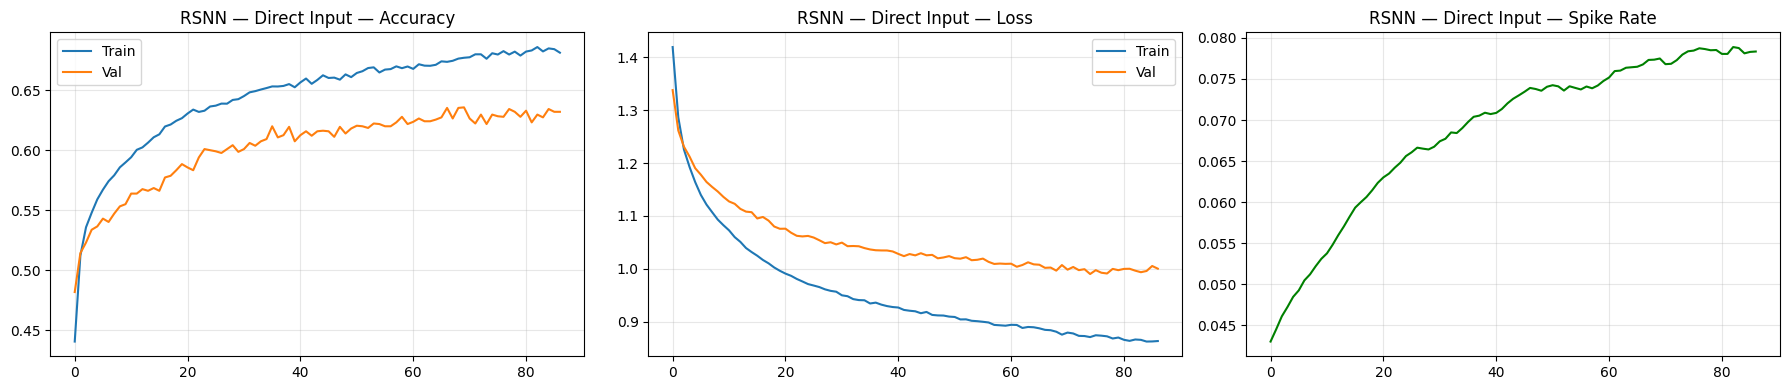

In [14]:
print("=" * 60)
print("EXPERIMENT 1: RSNN — Direct Input (no spike encoding)")
print("=" * 60)

# dt = 10000ms / 250 bins = 40ms per bin
model_direct = SNN(
    input_size=12,        # 12 ECG leads
    hidden_size=256,
    output_size=n_classes,
    n_hidden_layers=1,
    recurrent=True,
    tau_mem=40.0,         # Adjusted for 40ms timestep
    tau_syn=20.0,
    dt=40.0,              # 10s / 250 bins = 40ms
    learnable_tau=True,
    loss_mode='max_over_time',
    dropout=0.3
)
print(f"Model: {model_direct.count_params():,} params | 12 -> 256 RLIF -> {n_classes}")

trainer_direct = Trainer(model_direct, train_loader, val_loader, test_loader, lr=1e-3, device=device)
acc_direct = trainer_direct.train(n_epochs=100, patience=20)
trainer_direct.plot_history("RSNN — Direct Input")

## 8b. Experiment 2: RSNN with Rate Coding

Rate coding: normalise signal to [0,1] and treat values as spike probabilities. Generates stochastic binary spikes each timestep. Input stays at 12 channels.

EXPERIMENT 2: RSNN — Rate Coding
Encoding: rate | Input: [250, 12] | Classes: 5
Train: 17100 | Val: 2155 | Test: 2162
Model: 69,890 params | 12 -> 256 RLIF -> 5
Epoch   0/100 | Train: 0.4186 | Val: 0.4450 | Spk: 0.0431 | Best: 0.4450 | Pat: 20/20 | 42.1s
Epoch   5/100 | Train: 0.4948 | Val: 0.4965 | Spk: 0.0939 | Best: 0.4965 | Pat: 20/20 | 41.2s
Epoch  10/100 | Train: 0.5094 | Val: 0.5058 | Spk: 0.1246 | Best: 0.5049 | Pat: 16/20 | 42.2s
Epoch  15/100 | Train: 0.5157 | Val: 0.5128 | Spk: 0.1440 | Best: 0.5169 | Pat: 18/20 | 42.3s
Epoch  20/100 | Train: 0.5197 | Val: 0.5202 | Spk: 0.1731 | Best: 0.5202 | Pat: 20/20 | 41.5s
Epoch  25/100 | Train: 0.5220 | Val: 0.5086 | Spk: 0.1881 | Best: 0.5202 | Pat: 15/20 | 41.4s
Epoch  30/100 | Train: 0.5210 | Val: 0.5183 | Spk: 0.1951 | Best: 0.5225 | Pat: 19/20 | 41.5s
Epoch  35/100 | Train: 0.5215 | Val: 0.5123 | Spk: 0.2258 | Best: 0.5225 | Pat: 14/20 | 41.6s
Epoch  40/100 | Train: 0.5190 | Val: 0.5155 | Spk: 0.2492 | Best: 0.5225 | Pat: 9/20 | 

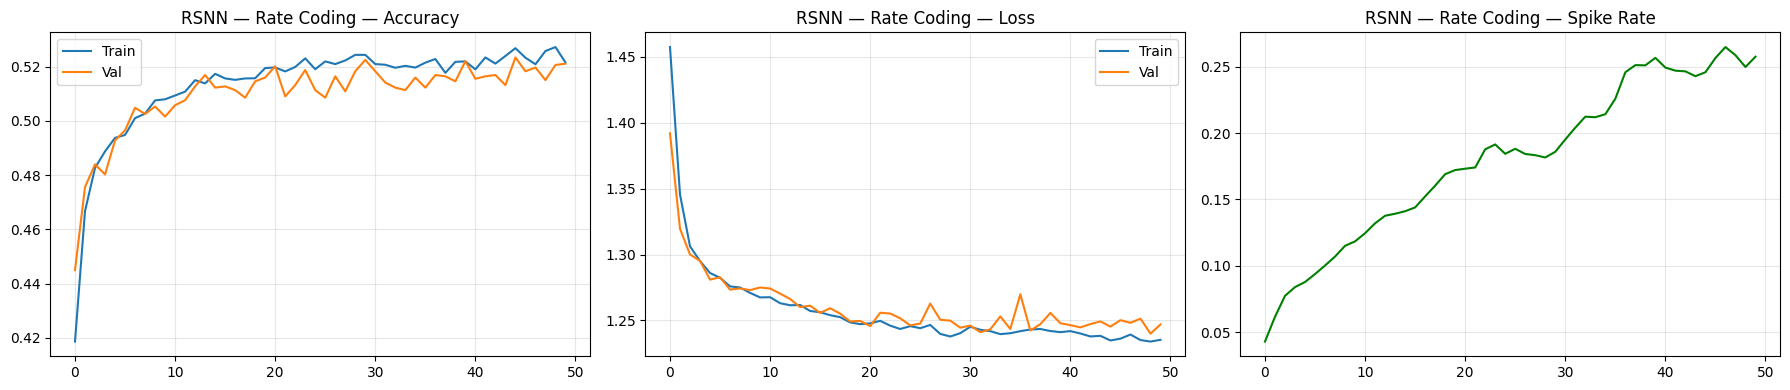

In [15]:
print("=" * 60)
print("EXPERIMENT 2: RSNN — Rate Coding")
print("=" * 60)

train_loader_rc, val_loader_rc, test_loader_rc, input_size_rc, _ = create_ecg_loaders(
    X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test,
    encoding='rate', n_time_bins=250, batch_size=128
)

model_rc = SNN(
    input_size=input_size_rc,  # 12
    hidden_size=256,
    output_size=n_classes,
    n_hidden_layers=1,
    recurrent=True,
    tau_mem=40.0, tau_syn=20.0, dt=40.0,
    learnable_tau=True,
    loss_mode='max_over_time',
    dropout=0.3
)
print(f"Model: {model_rc.count_params():,} params | {input_size_rc} -> 256 RLIF -> {n_classes}")

trainer_rc = Trainer(model_rc, train_loader_rc, val_loader_rc, test_loader_rc, lr=1e-3, device=device)
acc_rc = trainer_rc.train(n_epochs=100, patience=20)
trainer_rc.plot_history("RSNN — Rate Coding")

## 8c. Experiment 3: RSNN with Temporal Contrast Encoding

Spikes when the ECG derivative exceeds a threshold. Doubles input channels (ON + OFF spikes). Neurobiologically motivated — well-suited to ECG R-peaks.

EXPERIMENT 3: RSNN — Temporal Contrast Encoding
Encoding: temporal_contrast | Input: [250, 24] | Classes: 5
Train: 17100 | Val: 2155 | Test: 2162
Model: 72,962 params | 24 -> 256 RLIF -> 5
Epoch   0/100 | Train: 0.4292 | Val: 0.4343 | Spk: 0.0049 | Best: 0.4343 | Pat: 20/20 | 42.0s
Epoch   5/100 | Train: 0.5547 | Val: 0.5364 | Spk: 0.0160 | Best: 0.5364 | Pat: 20/20 | 42.3s
Epoch  10/100 | Train: 0.5803 | Val: 0.5633 | Spk: 0.0233 | Best: 0.5633 | Pat: 20/20 | 42.2s
Epoch  15/100 | Train: 0.5993 | Val: 0.5903 | Spk: 0.0296 | Best: 0.5903 | Pat: 20/20 | 41.7s
Epoch  20/100 | Train: 0.6108 | Val: 0.6005 | Spk: 0.0362 | Best: 0.6019 | Pat: 17/20 | 43.0s
Epoch  25/100 | Train: 0.6195 | Val: 0.6019 | Spk: 0.0418 | Best: 0.6019 | Pat: 12/20 | 41.9s
Epoch  30/100 | Train: 0.6264 | Val: 0.6116 | Spk: 0.0424 | Best: 0.6130 | Pat: 17/20 | 42.2s
Epoch  35/100 | Train: 0.6309 | Val: 0.6130 | Spk: 0.0475 | Best: 0.6162 | Pat: 17/20 | 41.7s
Epoch  40/100 | Train: 0.6340 | Val: 0.6148 | Spk: 0.0473 |

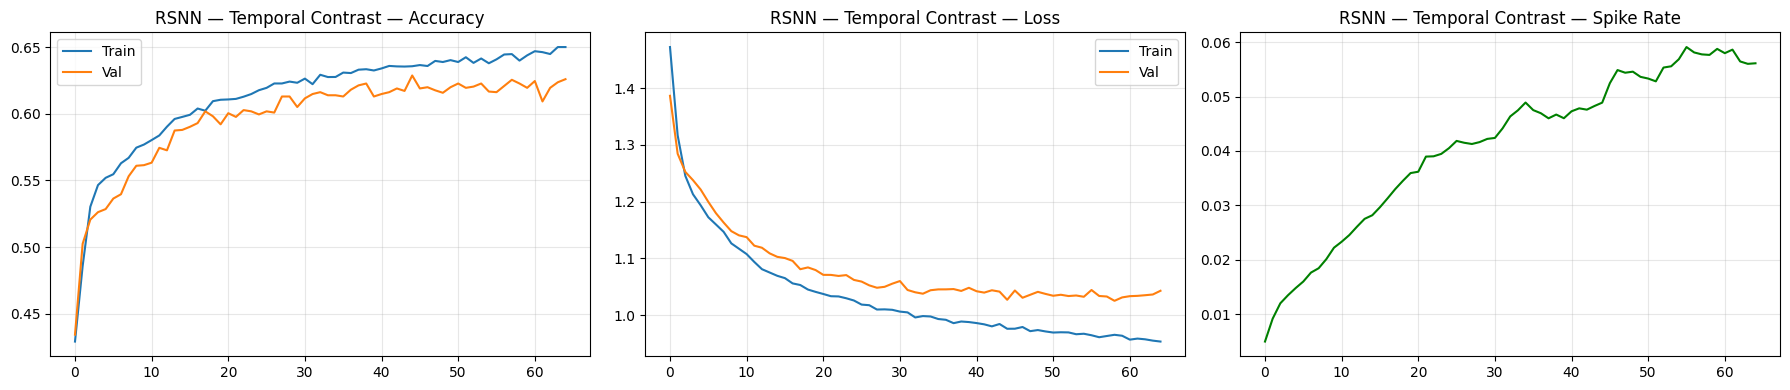

In [16]:
print("=" * 60)
print("EXPERIMENT 3: RSNN — Temporal Contrast Encoding")
print("=" * 60)

train_loader_tc, val_loader_tc, test_loader_tc, input_size_tc, _ = create_ecg_loaders(
    X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test,
    encoding='temporal_contrast', n_time_bins=250, batch_size=128, threshold=0.5
)

model_tc = SNN(
    input_size=input_size_tc,  # 24 (12 ON + 12 OFF channels)
    hidden_size=256,
    output_size=n_classes,
    n_hidden_layers=1,
    recurrent=True,
    tau_mem=40.0, tau_syn=20.0, dt=40.0,
    learnable_tau=True,
    loss_mode='max_over_time',
    dropout=0.3
)
print(f"Model: {model_tc.count_params():,} params | {input_size_tc} -> 256 RLIF -> {n_classes}")

trainer_tc = Trainer(model_tc, train_loader_tc, val_loader_tc, test_loader_tc, lr=1e-3, device=device)
acc_tc = trainer_tc.train(n_epochs=100, patience=20)
trainer_tc.plot_history("RSNN — Temporal Contrast")

## 9. Experiment 4: RSNN with Delta Modulation

EXPERIMENT 4: RSNN — Delta Modulation Encoding
Encoding: delta | Input: [250, 12] | Classes: 5
Train: 17100 | Val: 2155 | Test: 2162
Model: 69,890 params
Epoch   0/100 | Train: 0.4369 | Val: 0.4803 | Spk: 0.0150 | Best: 0.4803 | Pat: 20/20 | 48.4s
Epoch   5/100 | Train: 0.5944 | Val: 0.5824 | Spk: 0.0241 | Best: 0.5819 | Pat: 19/20 | 48.1s
Epoch  10/100 | Train: 0.6192 | Val: 0.6000 | Spk: 0.0318 | Best: 0.5995 | Pat: 18/20 | 47.7s
Epoch  15/100 | Train: 0.6344 | Val: 0.6102 | Spk: 0.0386 | Best: 0.6102 | Pat: 20/20 | 47.9s
Epoch  20/100 | Train: 0.6423 | Val: 0.6195 | Spk: 0.0432 | Best: 0.6195 | Pat: 20/20 | 47.9s
Epoch  25/100 | Train: 0.6461 | Val: 0.6223 | Spk: 0.0483 | Best: 0.6251 | Pat: 18/20 | 49.9s
Epoch  30/100 | Train: 0.6489 | Val: 0.6218 | Spk: 0.0510 | Best: 0.6278 | Pat: 19/20 | 48.6s
Epoch  35/100 | Train: 0.6544 | Val: 0.6269 | Spk: 0.0518 | Best: 0.6278 | Pat: 14/20 | 48.5s
Epoch  40/100 | Train: 0.6581 | Val: 0.6172 | Spk: 0.0535 | Best: 0.6306 | Pat: 19/20 | 48.7s


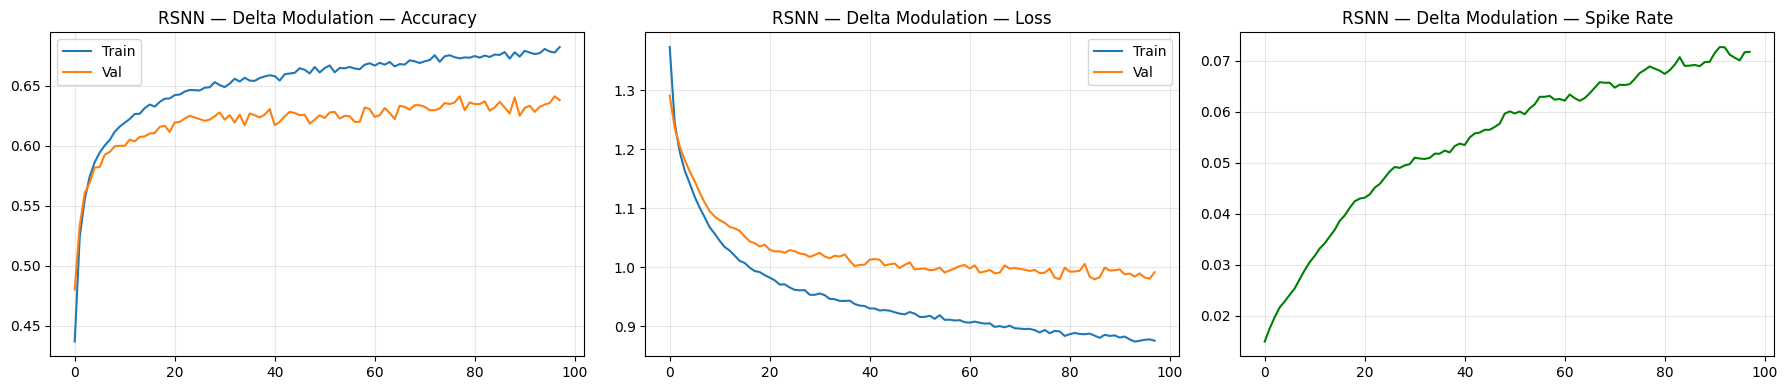

In [17]:
print("=" * 60)
print("EXPERIMENT 4: RSNN — Delta Modulation Encoding")
print("=" * 60)

train_loader_dm, val_loader_dm, test_loader_dm, input_size_dm, _ = create_ecg_loaders(
    X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test,
    encoding='delta', n_time_bins=250, batch_size=128, threshold=0.3
)

model_dm = SNN(
    input_size=input_size_dm,  # 12
    hidden_size=256,
    output_size=n_classes,
    n_hidden_layers=1,
    recurrent=True,
    tau_mem=40.0, tau_syn=20.0, dt=40.0,
    learnable_tau=True,
    loss_mode='max_over_time',
    dropout=0.3
)
print(f"Model: {model_dm.count_params():,} params")

trainer_dm = Trainer(model_dm, train_loader_dm, val_loader_dm, test_loader_dm, lr=1e-3, device=device)
acc_dm = trainer_dm.train(n_epochs=100, patience=20)
trainer_dm.plot_history("RSNN — Delta Modulation")

## 10. Baselines: LSTM & 1D-CNN

Train conventional models on the same data for fair comparison. Match parameter counts roughly

In [18]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, n_layers=2, output_size=5, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CNNBaseline(nn.Module):
    def __init__(self, input_channels=12, output_size=5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=11, padding=5),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=7, padding=3),
            nn.BatchNorm1d(256), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(256, output_size)
    def forward(self, x):
        # x: [B, T, C] -> [B, C, T]
        x = x.permute(0, 2, 1)
        x = self.conv(x).squeeze(-1)
        return self.fc(x)
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def train_baseline(model, train_loader, val_loader, test_loader, n_epochs=60, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_acc, best_state = 0, None
    
    for epoch in range(n_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch}: val_acc={val_acc:.4f} (best={best_val_acc:.4f})")
    
    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.size(0)
    test_acc = correct / total
    print(f"  Best val: {best_val_acc*100:.2f}% | Test: {test_acc*100:.2f}%")
    return test_acc

# LSTM
print("=" * 60)
print("BASELINE: LSTM (2-layer, 128 units)")
print("=" * 60)
model_lstm = LSTMBaseline(input_size=12, hidden_size=128, n_layers=2, output_size=n_classes)
print(f"LSTM params: {model_lstm.count_params():,}")
acc_lstm = train_baseline(model_lstm, train_loader, val_loader, test_loader)

# CNN
print("\n" + "=" * 60)
print("BASELINE: 1D-CNN")
print("=" * 60)
model_cnn = CNNBaseline(input_channels=12, output_size=n_classes)
print(f"CNN params: {model_cnn.count_params():,}")
acc_cnn = train_baseline(model_cnn, train_loader, val_loader, test_loader)

BASELINE: LSTM (2-layer, 128 units)
LSTM params: 205,445
  Epoch 0: val_acc=0.5021 (best=0.5021)
  Epoch 10: val_acc=0.6329 (best=0.6329)
  Epoch 20: val_acc=0.6561 (best=0.6687)
  Epoch 30: val_acc=0.6794 (best=0.6821)
  Epoch 40: val_acc=0.6696 (best=0.6872)
  Epoch 50: val_acc=0.6719 (best=0.6872)
  Best val: 68.72% | Test: 67.07%

BASELINE: 1D-CNN
CNN params: 333,637
  Epoch 0: val_acc=0.6501 (best=0.6501)
  Epoch 10: val_acc=0.6176 (best=0.6849)
  Epoch 20: val_acc=0.5012 (best=0.6849)
  Epoch 30: val_acc=0.5958 (best=0.6849)
  Epoch 40: val_acc=0.6209 (best=0.6849)
  Epoch 50: val_acc=0.5731 (best=0.6849)
  Best val: 68.49% | Test: 66.28%


## 11. Temporal Analysis (Best SNN Model)

Best SNN: Delta Modulation (63.23%)


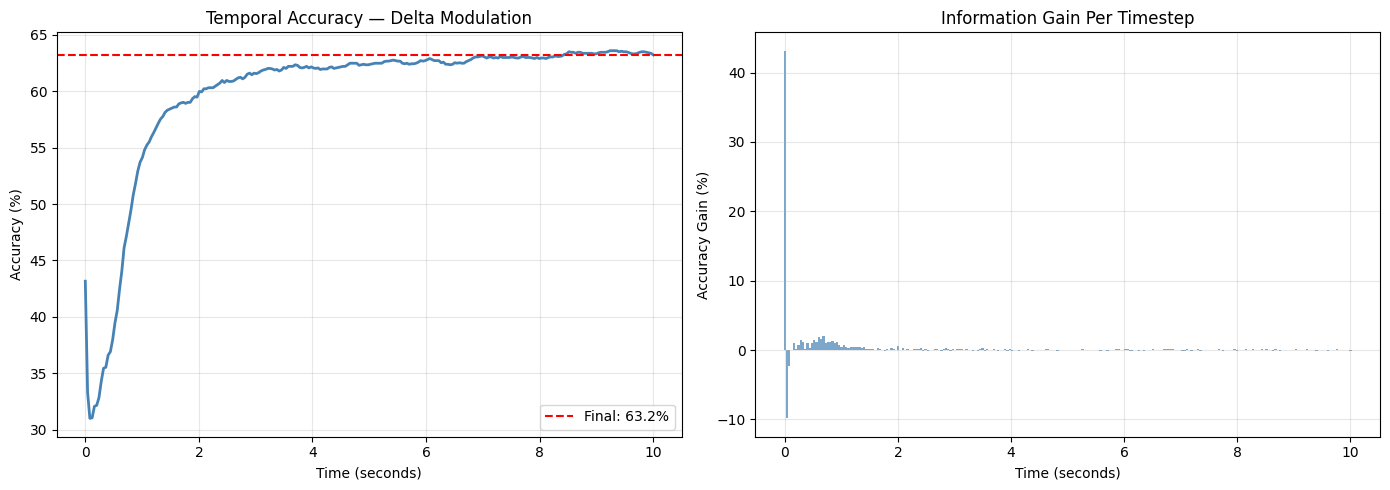

  2.5s: 61.0%
  5.0s: 62.4%
  7.5s: 63.0%
  9.9s: 63.4%


In [19]:
# Find best SNN model
best_snn_name = "Direct"
best_snn_acc = acc_direct
best_snn_model = model_direct
best_snn_loader = test_loader

for name, acc, model, loader in [
    ("Rate Coding", acc_rc, model_rc, test_loader_rc),
    ("Temporal Contrast", acc_tc, model_tc, test_loader_tc),
    ("Delta Modulation", acc_dm, model_dm, test_loader_dm),
]:
    if acc > best_snn_acc:
        best_snn_name, best_snn_acc, best_snn_model, best_snn_loader = name, acc, model, loader

print(f"Best SNN: {best_snn_name} ({best_snn_acc*100:.2f}%)")

@torch.no_grad()
def temporal_analysis(model, loader, device, n_classes=5):
    model.eval()
    all_correct_at_t = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, _, out_mem = model(x)
        B, T, C = out_mem.shape
        running_max = torch.full((B, C), -float('inf'), device=device)
        correct_at_t = torch.zeros(T, device=device)
        for t in range(T):
            running_max = torch.max(running_max, out_mem[:, t, :])
            correct_at_t[t] += (running_max.argmax(dim=1) == y).float().sum()
        all_correct_at_t.append(correct_at_t)
    total = torch.stack(all_correct_at_t).sum(dim=0)
    total_samples = sum(len(y) for _, y in loader)
    return (total / total_samples).cpu().numpy()

temporal_acc = temporal_analysis(best_snn_model, best_snn_loader, device, n_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
t_sec = np.linspace(0, 10, len(temporal_acc))
axes[0].plot(t_sec, temporal_acc * 100, linewidth=2, color='steelblue')
axes[0].axhline(y=best_snn_acc * 100, color='red', linestyle='--', label=f'Final: {best_snn_acc*100:.1f}%')
axes[0].set_xlabel('Time (seconds)'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title(f'Temporal Accuracy — {best_snn_name}'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

acc_gain = np.diff(temporal_acc * 100, prepend=0)
axes[1].bar(t_sec, acc_gain, width=t_sec[1]-t_sec[0], alpha=0.7, color='steelblue')
axes[1].set_xlabel('Time (seconds)'); axes[1].set_ylabel('Accuracy Gain (%)')
axes[1].set_title('Information Gain Per Timestep'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Key timepoints
for frac, label in [(0.25, "2.5s"), (0.5, "5.0s"), (0.75, "7.5s"), (0.99, "9.9s")]:
    idx = int(frac * len(temporal_acc))
    print(f"  {label}: {temporal_acc[idx]*100:.1f}%")

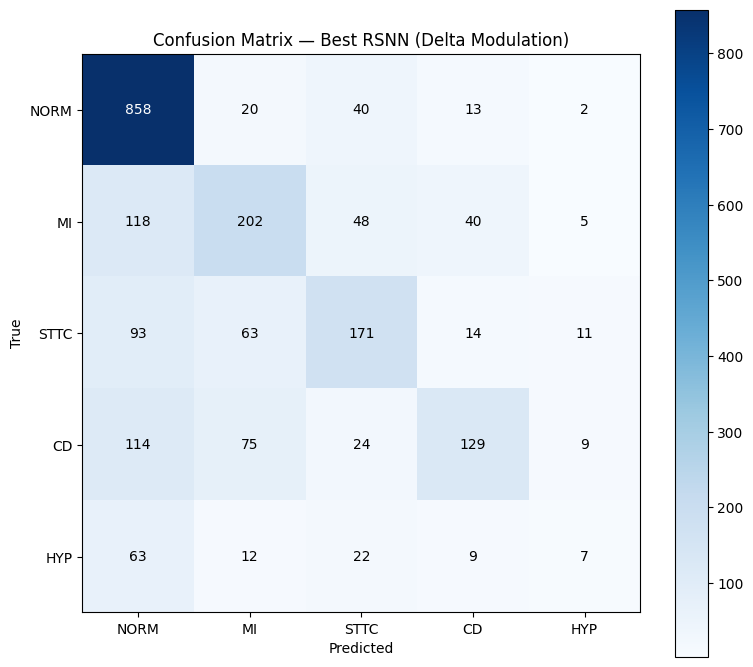

              precision    recall  f1-score   support

        NORM       0.69      0.92      0.79       933
          MI       0.54      0.49      0.51       413
        STTC       0.56      0.49      0.52       352
          CD       0.63      0.37      0.46       351
         HYP       0.21      0.06      0.10       113

    accuracy                           0.63      2162
   macro avg       0.53      0.46      0.48      2162
weighted avg       0.61      0.63      0.60      2162



In [20]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    preds, labels = [], []
    for x, y in loader:
        logits, _, _ = model(x.to(device))
        preds.append(logits.argmax(1).cpu())
        labels.append(y)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()

preds, labels = get_predictions(best_snn_model, best_snn_loader, device)
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(n_classes)); ax.set_xticklabels(SUPERCLASSES)
ax.set_yticks(range(n_classes)); ax.set_yticklabels(SUPERCLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Best RSNN ({best_snn_name})')
plt.colorbar(im)
for i in range(n_classes):
    for j in range(n_classes):
        if cm[i, j] > 0:
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=10)
plt.tight_layout(); plt.show()

print(classification_report(labels, preds, target_names=SUPERCLASSES))

## 12. Results Summary

In [21]:
print("=" * 70)
print("RESULTS — PTB-XL ECG Classification")
print("=" * 70)
print(f"{'Model':<35} {'Test Acc':>10} {'Params':>10}")
print("-" * 70)
results = {
    'RSNN Direct Input': acc_direct,
    'RSNN Rate Coding': acc_rc,
    'RSNN Temporal Contrast': acc_tc,
    'RSNN Delta Modulation': acc_dm,
    'LSTM (2L, 128)': acc_lstm,
    '1D-CNN': acc_cnn,
}
for name, acc in results.items():
    params = "-"
    if "Direct" in name: params = f"{model_direct.count_params():,}"
    elif "Rate" in name: params = f"{model_rc.count_params():,}"
    elif "Temporal" in name: params = f"{model_tc.count_params():,}"
    elif "Delta" in name: params = f"{model_dm.count_params():,}"
    elif "LSTM" in name: params = f"{model_lstm.count_params():,}"
    elif "CNN" in name: params = f"{model_cnn.count_params():,}"
    print(f"  {name:<33} {acc*100:>8.2f}% {params:>10}")
print("-" * 70)
print(f"  Best SNN encoding: {best_snn_name}")

import json
with open('/kaggle/working/ecg_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved to ecg_results.json")

RESULTS — PTB-XL ECG Classification
Model                                 Test Acc     Params
----------------------------------------------------------------------
  RSNN Direct Input                    61.24%     69,890
  RSNN Rate Coding                     50.19%     69,890
  RSNN Temporal Contrast               61.05%     72,962
  RSNN Delta Modulation                63.23%     69,890
  LSTM (2L, 128)                       67.07%    205,445
  1D-CNN                               66.28%    333,637
----------------------------------------------------------------------
  Best SNN encoding: Delta Modulation

Saved to ecg_results.json


In [22]:
torch.save({
    'model_state_dict': best_snn_model.state_dict(),
    'model_config': dict(input_size=best_snn_model.hidden_layers[0].input_size,
                         hidden_size=256, output_size=n_classes,
                         n_hidden_layers=1, recurrent=True,
                         tau_mem=40.0, tau_syn=20.0, dt=40.0,
                         learnable_tau=True, loss_mode='max_over_time', dropout=0.3),
    'best_encoding': best_snn_name,
    'test_acc': best_snn_acc,
    'results': results,
}, '/kaggle/working/best_rsnn_ecg.pth')
print(f"Saved best model ({best_snn_name}, {best_snn_acc*100:.2f}%)")

Saved best model (Delta Modulation, 63.23%)


## 13. LSTM Temporal Analysis

Same idea as the SNN temporal analysis above — at each timestep t, how well can the model classify?

The LSTM hidden state h_t summarises everything it has seen up to t. So we take h_t, pass it through the fc head, and use running-max across timesteps (same as SNN). This makes the comparison fair.

In [23]:
@torch.no_grad()
def lstm_temporal_analysis(model, test_loader, device, n_classes=5):
    """Classify from LSTM hidden state at each timestep with running max."""
    model.eval()
    all_correct_at_t = []

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        # get hidden states at every timestep
        hidden_seq, _ = model.lstm(x)  # [B, T, hidden_size]
        B, T, H = hidden_seq.shape

        # classify from each h_t
        logits_seq = model.fc(hidden_seq)  # [B, T, n_classes]

        # running max over logits — same as SNN's running max over readout membrane
        running_max = torch.full((B, n_classes), -float('inf'), device=device)
        correct_at_t = torch.zeros(T, device=device)
        for t in range(T):
            running_max = torch.max(running_max, logits_seq[:, t, :])
            correct_at_t[t] += (running_max.argmax(dim=1) == y).float().sum()
        all_correct_at_t.append(correct_at_t)

    total_correct = torch.stack(all_correct_at_t).sum(dim=0)
    total_samples = sum(len(y) for _, y in test_loader)
    return (total_correct / total_samples).cpu().numpy()


lstm_temporal = lstm_temporal_analysis(model_lstm, test_loader, device, n_classes)

for frac, label in [(0.25, "2.5s"), (0.5, "5.0s"), (0.75, "7.5s"), (0.99, "9.9s")]:
    idx = int(frac * len(lstm_temporal))
    print(f"  LSTM at {label}: {lstm_temporal[idx]*100:.1f}%")

  LSTM at 2.5s: 50.7%
  LSTM at 5.0s: 61.4%
  LSTM at 7.5s: 64.4%
  LSTM at 9.9s: 65.7%


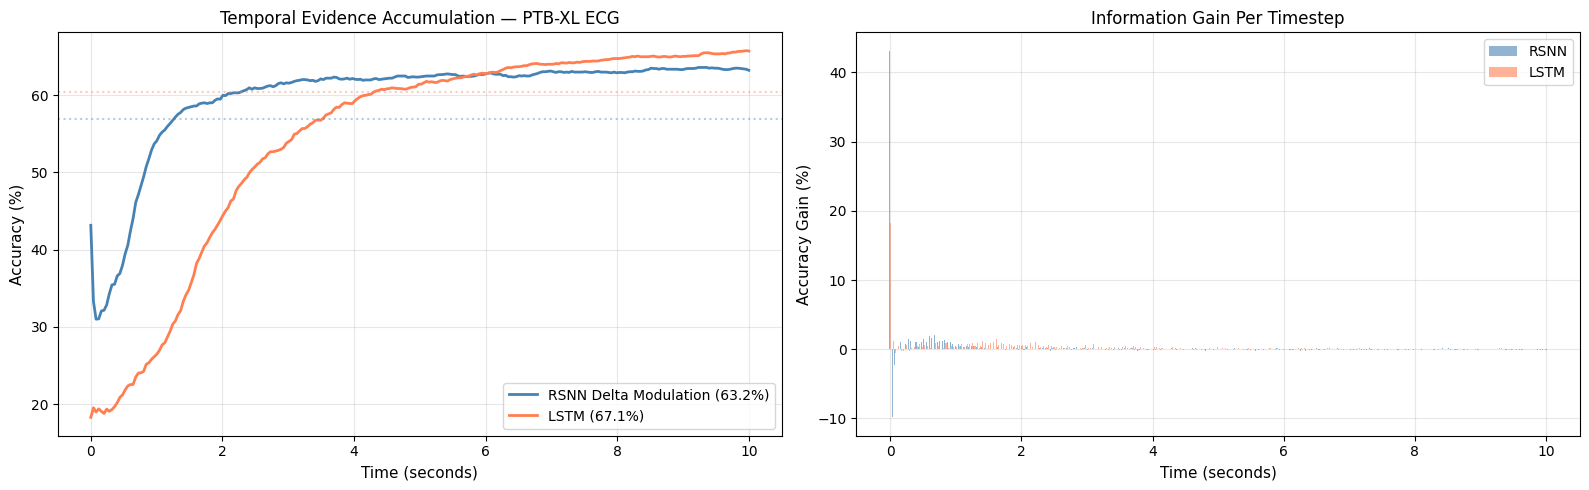

In [24]:
# both temporal_acc (SNN) and lstm_temporal have 250 entries
t_sec = np.linspace(0, 10, len(temporal_acc))
t_sec_lstm = np.linspace(0, 10, len(lstm_temporal))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- temporal curves ---
axes[0].plot(t_sec, temporal_acc * 100, linewidth=2, color='steelblue',
             label=f'RSNN {best_snn_name} ({best_snn_acc*100:.1f}%)')
axes[0].plot(t_sec_lstm, lstm_temporal * 100, linewidth=2, color='coral',
             label=f'LSTM ({acc_lstm*100:.1f}%)')

rsnn_90 = 0.9 * best_snn_acc * 100
lstm_90 = 0.9 * acc_lstm * 100
axes[0].axhline(y=rsnn_90, color='steelblue', linestyle=':', alpha=0.4)
axes[0].axhline(y=lstm_90, color='coral', linestyle=':', alpha=0.4)

axes[0].set_xlabel('Time (seconds)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Temporal Evidence Accumulation — PTB-XL ECG', fontsize=12)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# --- information gain ---
rsnn_gain = np.diff(temporal_acc * 100, prepend=0)
lstm_gain = np.diff(lstm_temporal * 100, prepend=0)
w = (t_sec[1] - t_sec[0]) * 0.4
axes[1].bar(t_sec - w/2, rsnn_gain, width=w, alpha=0.6, color='steelblue', label='RSNN')
axes[1].bar(t_sec_lstm + w/2, lstm_gain, width=w, alpha=0.6, color='coral', label='LSTM')
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('Accuracy Gain (%)', fontsize=11)
axes[1].set_title('Information Gain Per Timestep', fontsize=12)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# time-to-90%-of-ceiling
rsnn_ceiling = best_snn_acc
lstm_ceiling = acc_lstm

rsnn_90_th = 0.9 * rsnn_ceiling
lstm_90_th = 0.9 * lstm_ceiling

rsnn_t90_idx = np.argmax(temporal_acc >= rsnn_90_th)
lstm_t90_idx = np.argmax(lstm_temporal >= lstm_90_th)

rsnn_t90_s = t_sec[rsnn_t90_idx]
lstm_t90_s = t_sec_lstm[lstm_t90_idx]

print("=" * 60)
print("TEMPORAL EFFICIENCY — PTB-XL ECG")
print("=" * 60)
print(f"{'':>25} {'RSNN':>12} {'LSTM':>12}")
print("-" * 50)
print(f"  {'Ceiling accuracy':<23} {rsnn_ceiling*100:>10.1f}% {lstm_ceiling*100:>10.1f}%")
print(f"  {'90% of ceiling':<23} {rsnn_90_th*100:>10.1f}% {lstm_90_th*100:>10.1f}%")
print(f"  {'Time to 90%':<23} {rsnn_t90_s:>10.1f}s {lstm_t90_s:>10.1f}s")
print(f"  {'% of 10s recording':<23} {rsnn_t90_s*10:>10.0f}% {lstm_t90_s*10:>10.0f}%")
print("-" * 50)
if rsnn_t90_s > 0 and lstm_t90_s > 0:
    print(f"  LSTM needs {lstm_t90_s/rsnn_t90_s:.1f}x longer than RSNN")

TEMPORAL EFFICIENCY — PTB-XL ECG
                                  RSNN         LSTM
--------------------------------------------------
  Ceiling accuracy              63.2%       67.1%
  90% of ceiling                56.9%       60.4%
  Time to 90%                    1.3s        4.3s
  % of 10s recording              13%         43%
--------------------------------------------------
  LSTM needs 3.3x longer than RSNN


## 14. Comparative Results Summary

In [26]:
print("=" * 70)
print("FULL RESULTS — PTB-XL ECG Classification")
print("=" * 70)
print(f"{'Model':<35} {'Test Acc':>10} {'Params':>10}")
print("-" * 70)
all_results = [
    ('RSNN Direct Input', acc_direct, model_direct.count_params()),
    ('RSNN Rate Coding', acc_rc, model_rc.count_params()),
    ('RSNN Temporal Contrast', acc_tc, model_tc.count_params()),
    ('RSNN Delta Modulation', acc_dm, model_dm.count_params()),
    ('LSTM (2L, 128)', acc_lstm, model_lstm.count_params()),
    ('1D-CNN', acc_cnn, model_cnn.count_params()),
]
for name, acc, params in all_results:
    print(f"  {name:<33} {acc*100:>8.2f}% {params:>10,}")
print("-" * 70)
print()
print("Temporal efficiency:")
print(f"  RSNN reaches 90% of {rsnn_ceiling*100:.1f}% at {rsnn_t90_s:.1f}s")
print(f"  LSTM reaches 90% of {lstm_ceiling*100:.1f}% at {lstm_t90_s:.1f}s")

FULL RESULTS — PTB-XL ECG Classification
Model                                 Test Acc     Params
----------------------------------------------------------------------
  RSNN Direct Input                    61.24%     69,890
  RSNN Rate Coding                     50.19%     69,890
  RSNN Temporal Contrast               61.05%     72,962
  RSNN Delta Modulation                63.23%     69,890
  LSTM (2L, 128)                       67.07%    205,445
  1D-CNN                               66.28%    333,637
----------------------------------------------------------------------

Temporal efficiency:
  RSNN reaches 90% of 63.2% at 1.3s
  LSTM reaches 90% of 67.1% at 4.3s


In [27]:
# save temporal data for cross-domain comparison later
np.savez('/kaggle/working/ecg_temporal.npz',
         rsnn=temporal_acc, lstm=lstm_temporal,
         rsnn_ceiling=rsnn_ceiling, lstm_ceiling=lstm_ceiling,
         rsnn_t90_s=rsnn_t90_s, lstm_t90_s=lstm_t90_s)

import json
ecg_full = {
    'results': {name: acc for name, acc, _ in all_results},
    'temporal': {
        'rsnn_t90_s': float(rsnn_t90_s),
        'lstm_t90_s': float(lstm_t90_s),
    },
    'best_snn': best_snn_name,
}
with open('/kaggle/working/ecg_full_results.json', 'w') as f:
    json.dump(ecg_full, f, indent=2)
print("Saved to ecg_temporal.npz and ecg_full_results.json")

Saved to ecg_temporal.npz and ecg_full_results.json
